In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
from clients.opensearch_client import WorkflowDBClient

%matplotlib ipympl

In [2]:
wf = WorkflowDBClient()

def print_sim_result(df, pnum: int, qg: str = "paragraph", cg: str="paragraph", doc_name: str="OTPP", max_len:int=10, tag_name: str= "Disclosing Party Name"):
    reduced_df = df.query(f"pnum=={pnum} & tag_name=='{tag_name}' & query_granularity=='{qg}' & corpus_granularity=='{cg}' & doc_name.str.contains('{doc_name}')")
    print("SOURCE :  \n" + list(set(reduced_df.source_text))[0])
    print("\n\n ######## RETRIEVED \n")
    print("\n\n ######## \n".join(reduced_df.sort_values("nneighbours").reset_index(drop=True).text.iloc[:max_len].tolist()))
    return reduced_df

In [3]:
key = "ottp_topology_df_tag_CI Exclusion Third Party Receipt.pkl"
tag_name = key.split("_")[-1].strip(".pkl")
data = wf.s3.get_object(Bucket="homology-experiment", Key=key)["Body"]
df = pd.read_pickle(io.BytesIO(data.read()))

#df = pd.read_pickle("/Users/thomas.barillot/AvantiaTech/data_platform/scripts/ottp_topology_analysis/outputs/ottp_topology_df.pkl")
df["query_tokens"] = df.source_text.apply(lambda x: len(x.split()))

In [4]:
BUCKET = "homology-experiment"

paginator = wf.s3.get_paginator("list_objects_v2")
all_keys = [
    obj["Key"]
    for page in paginator.paginate(Bucket=BUCKET)
    for obj in page.get("Contents", [])
]
print(f"{len(all_keys)} objects found")
all_keys[:60]

68 objects found


['ottp_topology_df_tag_CI Definition Includes Derivatives.pkl',
 'ottp_topology_df_tag_CI Definition Includes Discussion Existence.pkl',
 'ottp_topology_df_tag_CI Definition Includes Third Party Info.pkl',
 'ottp_topology_df_tag_CI Definition Industry Specific Terms.pkl',
 'ottp_topology_df_tag_CI Definition Marking Required.pkl',
 'ottp_topology_df_tag_CI Definition Scope.pkl',
 'ottp_topology_df_tag_CI Definition Software Specific.pkl',
 'ottp_topology_df_tag_CI Exclusion Independent Development.pkl',
 'ottp_topology_df_tag_CI Exclusion Prior Knowledge.pkl',
 'ottp_topology_df_tag_CI Exclusion Public Domain.pkl',
 'ottp_topology_df_tag_CI Exclusion Third Party Receipt.pkl',
 'ottp_topology_df_tag_CI Exclusion Written Release.pkl',
 'ottp_topology_df_tag_Contact Restrictions Present.pkl',
 'ottp_topology_df_tag_Contact Restrictions Scope.pkl',
 'ottp_topology_df_tag_Counterparts.pkl',
 'ottp_topology_df_tag_Direction.pkl',
 'ottp_topology_df_tag_Disclosing Party Entity Type.pkl',
 'ot

In [4]:
import random

sample_keys = random.sample(all_keys, 60)

dfs = []
for key in sample_keys:
    data = wf.s3.get_object(Bucket=BUCKET, Key=key)["Body"]
    dfs.append(pd.read_pickle(io.BytesIO(data.read())))

df0 = pd.concat(dfs, ignore_index=True)
df0["query_tokens"] = df0.source_text.apply(lambda x: len(x.split()))
print(df0.shape)
df0.head()


df0.to_pickle("dump_df0.pkl")

(185827, 31)


In [5]:
df0 = pd.read_pickle("dump_df0.pkl")

In [6]:
uid_cols = ["tag_name", "doc_name", "pnum"]
df0["unique_id"] = df0[uid_cols].astype(str).agg(" | ".join, axis=1)

In [ ]:

sns.pairplot(df.query("cosine_similarity>.7")[["cosine_similarity", "token_similarity", "depsilon", "doc_name", "pnum"]], hue="doc_name")

In [ ]:
plt.figure()
sns.histplot(df["query_tokens"],bins=np.arange(0,200,4))

In [ ]:
df2[df2["unique_id"] == "CI Exclusion Third Party Receipt | ACM - Eide Bailly (OTPP) - Joinder - 2026.03.17 - Executed.pdf | 30"]

In [ ]:
def filter_groups(df):
    if any(df.cosine_similarity >0.8):
        return df
    return pd.DataFrame()

df2 = df.groupby(["doc_name","pnum","query_granularity"]).apply(lambda x: filter_groups(x)).reset_index(drop=True)

In [ ]:
df2

In [ ]:
sns.pairplot(df2[["cosine_similarity", "token_similarity", "depsilon","corpus_granularity", "pnum","w1_h0","h0_entropy","kl_divergence","cross_entropy", "nneighbours"]], hue="corpus_granularity")

In [ ]:
sns.pairplot(df2[["cosine_similarity","w1_h0","corpus_granularity"]], hue="corpus_granularity")

In [ ]:
len(above)

In [ ]:
from scipy import stats   
thresholds = np.linspace(0.2, 0.95, 40)                  
thresholds = np.linspace(0, 200, 200)
thresholds = np.linspace(0, 5, 50)                                                                                
t_stats, p_values, n_above = [], [], []
  
df3 = df2.query("query_granularity=='paragraph' & corpus_granularity=='sentence'")  
docnames = df3["doc_name"].unique()  
results = []                                                                                                                 
total_w1h0 = df3["w1_h0"].replace(np.infty, np.nan).dropna().values                                                                                      
                                                                                                                    
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)                                                    
                                                                                                                        
for docname, df_doc in df3.groupby("doc_name"):                                                                        
    total_w1h0 = df_doc["w1_h0"].values
    t_stats, p_values = [], []                                                                                        
                                                                                                                    
    for t in thresholds:                                                                                              
        above = df_doc[df_doc["cosine_similarity"] > t]["w1_h0"].values                                               
        if len(above) < 5:                                                                                            
            t_stats.append(np.nan)                                                                                    
            p_values.append(np.nan)                                                                                   
            continue                                                                                                  
        stat, p = stats.ttest_ind(above, total_w1h0, equal_var=False)                                                 
        t_stats.append(stat)                                                                                          
        p_values.append(p)                                                                                            
                                                                                                                    
    t_stats = np.array(t_stats)                                                                                       
    p_values = np.array(p_values)                                                                                     
    valid = ~np.isnan(t_stats)                                                                                        
                                                                                                                    
    if valid.any():                                                                                                   
        optimal_threshold = thresholds[valid][np.argmax(t_stats[valid])]                                              
        results.append({"docname": docname, "optimal_threshold": optimal_threshold})                                  
        label = f"{docname} (cut={optimal_threshold:.2f})"                                                            
        ax1.plot(thresholds, t_stats, label=label, alpha=0.7)                                                         
        ax2.plot(thresholds, p_values, alpha=0.7)                                                                     
                                                                                                                        
ax1.set_ylabel("t-statistic")                                                                                         
ax1.legend(fontsize=7, loc="upper left")                                                                              
ax1.axhline(0, color="k", linestyle="--", linewidth=0.8)                                                              
                                                                                                                    
ax2.axhline(0.05, color="r", linestyle="--", label="p=0.05")                                                          
ax2.set_ylabel("p-value")                                                                                             
ax2.set_xlabel("cosine_similarity threshold")                                                                         
ax2.set_yscale("log")                                                                                                 
ax2.legend(fontsize=8)                                                                                                
                                                                                                                    
plt.tight_layout()                                                                                                    
plt.show()                                                                                                            
                                                                                                                    
df_cutoffs = pd.DataFrame(results)                                                                                    
print(df_cutoffs)                                                                                                     
print(df_cutoffs["optimal_threshold"].describe()) 

In [ ]:
df2.query("query_granularity=='paragraph' & corpus_granularity=='chunk' & depsilon<=0.41").groupby(["pnum", "doc_name", "n_tagged"]).apply(lambda x: max(x.nneighbours)).reset_index()

In [ ]:
df2.query("query_granularity=='paragraph' & corpus_granularity=='paragraph' & depsilon<=0.1").groupby(["pnum", "doc_name", "n_tagged"]).apply(lambda x: max(x.nneighbours)).reset_index()

In [ ]:
df2.query("query_granularity=='paragraph' & corpus_granularity=='sentence' & depsilon<=0.2").groupby(["pnum", "doc_name", "n_tagged"]).apply(lambda x: max(x.nneighbours)).reset_index()

In [ ]:
def plot_sim_results(df, qg: str = "paragraph", cg: str="paragraph", tag_name: str= "Disclosing Party Name"):
    reduced_df = df.query(f"tag_name=='{tag_name}' & query_granularity=='{qg}' & corpus_granularity=='{cg}'")
    #print("SOURCE :  \n" + list(set(reduced_df.source_text))[0])
    #print("\n\n ######## RETRIEVED \n")
    #print("\n\n ######## \n".join(reduced_df.sort_values("nneighbours").reset_index(drop=True).text.iloc[:max_len].tolist()))
    


    fig, ax1 = plt.subplots() # initializes figure and plots

    ax2 = ax1.twinx() # applies twinx to ax2, which is the second y axis. 
    # plots the second set, and sets to ax2. 
    sns.lineplot(x=reduced_df.nneighbours, y=reduced_df.w1_h0, ax=ax1)
    sns.lineplot(x = reduced_df.nneighbours, y = reduced_df.cosine_similarity, marker = 'o', color = 'red', ax = ax2)
    for ntag in set(reduced_df.n_tagged):
        plt.axvline(ntag)

    # ax2 = ax1.twinx() # applies twinx to ax2, which is the second y axis. 
    # sns.lineplot(x=reduced_df.depsilon, y=reduced_df.w1_h0)
    # sns.lineplot(x = reduced_df.depsilon, y = reduced_df.cosine_similarity, marker = 'o', color = 'red', ax = ax2)
    return reduced_df
    

In [ ]:
rdf = plot_sim_results(df2, "paragraph", "sentence",tag_name)

In [ ]:
rdf

In [ ]:
rdf = plot_sim_results(df2, "paragraph", "paragraph",tag_name)

In [ ]:
rdf

In [ ]:
rdf = plot_sim_results(df2, "paragraph", "chunk",tag_name)

In [ ]:
rdf

In [ ]:
fig, ax1 = plt.subplots() # initializes figure and plots

ax2 = ax1.twinx() # applies twinx to ax2, which is the second y axis. 
 # plots the second set, and sets to ax2. 
sns.lineplot(x=rdf.nneighbours, y=rdf.w1_h0, ax=ax1)
sns.lineplot(x = rdf.nneighbours, y = rdf.cosine_similarity, marker = 'o', color = 'red', ax = ax2)
plt.axvline(rdf.n_tagged.iloc[0])

fig, ax1 = plt.subplots() # initializes figure and plots

ax2 = ax1.twinx() # applies twinx to ax2, which is the second y axis. 
sns.lineplot(x=rdf.depsilon, y=rdf.w1_h0)
sns.lineplot(x = rdf.depsilon, y = rdf.cosine_similarity, marker = 'o', color = 'red', ax = ax2)

In [ ]:
rdf

In [ ]:
df

In [ ]:
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter1d

uid_cols = ["tag_name", "doc_name", "pnum"]
df["unique_id"] = df[uid_cols].astype(str).agg(" | ".join, axis=1)

df_exploded = df.explode("h0_dist").dropna(subset=["h0_dist"])
df_exploded["h0_dist"] = df_exploded["h0_dist"].astype(float)

unique_ids = df["unique_id"].unique()
n = len(unique_ids)
ncols = 3
nrows = int(np.ceil(n / ncols))

x_vars = ["nneighbours", "depsilon", "cosine_similarity"]
corpus_granularities = ["chunk", "paragraph"]

H0_DIST_YMIN, H0_DIST_YMAX = 0, 1.4
N_YBINS = 40
y_bins = np.linspace(H0_DIST_YMIN, H0_DIST_YMAX, N_YBINS + 1)
y_mids = (y_bins[:-1] + y_bins[1:]) / 2
y_bin_width = (H0_DIST_YMAX - H0_DIST_YMIN) / N_YBINS

SMOOTH_COEFF = 0.2
EPS = 1e-12

def smooth_and_variance(counts, sigma_per_slice):
    normed_smooth = np.zeros_like(counts, dtype=float)
    for ix in range(counts.shape[0]):
        row = counts[ix].astype(float)
        row_sum = row.sum()
        if row_sum == 0:
            continue
        p = row / row_sum
        p_smooth = gaussian_filter1d(p, sigma=sigma_per_slice[ix], mode="constant", cval=0)
        p_smooth_sum = p_smooth.sum()
        if p_smooth_sum > 0:
            p_smooth /= p_smooth_sum
        normed_smooth[ix] = p_smooth
    mean = normed_smooth @ y_mids
    variance = normed_smooth @ (y_mids ** 2) - mean ** 2
    return normed_smooth, variance

def sigma_from_nneighbours(xedges, x_vals, nn_vals):
    sigmas = np.zeros(len(xedges) - 1)
    for ix in range(len(xedges) - 1):
        lo, hi = xedges[ix], xedges[ix + 1]
        mask = (x_vals >= lo) & (x_vals <= hi)
        nn_in_bin = nn_vals[mask]
        mean_nn = nn_in_bin.mean() if len(nn_in_bin) > 0 else 1.0
        sigmas[ix] = SMOOTH_COEFF / np.sqrt(max(mean_nn, 1.0)) / y_bin_width
    return sigmas

for x_var in x_vars:
    for cg in corpus_granularities:
        fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows), constrained_layout=True)
        axes = axes.flatten()

        for i, uid in enumerate(unique_ids):
            ax = axes[i]
            uid_cg_mask = (df["unique_id"] == uid) & (df["corpus_granularity"] == cg)

            subset_2d = df_exploded[
                (df_exploded["unique_id"] == uid) &
                (df_exploded["corpus_granularity"] == cg)
            ][[x_var, "h0_dist"]].dropna()

            if subset_2d.empty:
                ax.set_visible(False)
                continue

            counts, xedges, _ = np.histogram2d(subset_2d[x_var], subset_2d["h0_dist"],
                                               bins=[40, y_bins])

            df_uid = df[uid_cg_mask][[x_var, "nneighbours"]].dropna().reset_index(drop=True)
            x_vals = df_uid[x_var].to_numpy()
            nn_vals = df_uid["nneighbours"].to_numpy()
            sigma_per_slice = sigma_from_nneighbours(xedges, x_vals, nn_vals)

            normed_smooth, variance = smooth_and_variance(counts, sigma_per_slice)

            display = normed_smooth.copy()
            display[display == 0] = np.nan

            mesh = ax.pcolormesh(xedges, y_bins, display.T, cmap="viridis", norm=LogNorm())
            fig.colorbar(mesh, ax=ax, shrink=0.8, label="p(h0_dist | x) smoothed")
            ax.set_ylim(H0_DIST_YMIN, H0_DIST_YMAX)
            ax.set_xlabel(x_var, fontsize=8)
            ax.set_ylabel("h0_dist", fontsize=8)

            if x_var == "nneighbours":
                for nt in df[uid_cg_mask]["n_tagged"].dropna().unique():
                    ax.axvline(nt, color="black", linestyle="--", linewidth=1)

            x_mids = (xedges[:-1] + xedges[1:]) / 2

            ax2 = ax.twinx()
            ax2.plot(x_mids, variance, color="red", linewidth=1, alpha=0.8)
            ax2.set_ylabel("variance", fontsize=7, color="red")
            ax2.tick_params(axis="y", colors="red", labelsize=6)

            ax3 = ax.twinx()
            ax3.spines["right"].set_position(("outward", 45))
            kl = df[uid_cg_mask][[x_var, "kl_divergence"]].dropna().sort_values(x_var)
            ax3.plot(kl[x_var].to_numpy(), kl["kl_divergence"].to_numpy(), color="orange", linewidth=1, alpha=0.8)
            ax3.set_ylabel("kl_divergence", fontsize=7, color="orange")
            ax3.tick_params(axis="y", colors="orange", labelsize=6)

            ax.set_title(uid, fontsize=6, wrap=True)

        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle(
            f"h0_dist vs {x_var}  |  corpus={cg}  |  σ={SMOOTH_COEFF}/√nneighbours  (log color)",
            fontsize=11
        )
        plt.show()

In [ ]:
unique_ids

In [ ]:
from matplotlib.colors import TwoSlopeNorm

unique_ids = df["unique_id"].unique()
n = len(unique_ids)
ncols = 3
nrows = int(np.ceil(n / ncols))

for x_var in ["nneighbours","depsilon", "cosine_similarity"]:
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), constrained_layout=True)
    axes = axes.flatten()

    for i, uid in enumerate(unique_ids):
        ax = axes[i]
        base = df_exploded[df_exploded["unique_id"] == uid][[x_var, "h0_dist", "corpus_granularity"]].dropna()

        chunk_data     = base[base["corpus_granularity"] == "chunk"]
        paragraph_data = base[base["corpus_granularity"] == "paragraph"]

        if chunk_data.empty or paragraph_data.empty:
            ax.set_visible(False)
            continue

        # shared bin edges so the arrays align
        x_bins = np.linspace(base[x_var].min(), base[x_var].max(), 41)
        y_bins = np.linspace(base["h0_dist"].min(), base["h0_dist"].max(), 41)

        def norm_hist(data):
            counts, _, _ = np.histogram2d(data[x_var], data["h0_dist"], bins=[x_bins, y_bins])
            col_sums = counts.sum(axis=1, keepdims=True)
            col_sums[col_sums == 0] = 1
            return counts / col_sums

        diff = norm_hist(chunk_data) - norm_hist(paragraph_data)

        vmax = np.nanmax(np.abs(diff))
        mesh = ax.pcolormesh(x_bins, y_bins, diff.T, cmap="RdBu_r",
                             norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax))
        fig.colorbar(mesh, ax=ax, shrink=0.8, label="chunk − paragraph")
        ax.set_title(uid, fontsize=6, wrap=True)
        ax.set_xlabel(x_var, fontsize=8)
        ax.set_ylabel("h0_dist", fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"Difference map (chunk − paragraph)  |  h0_dist vs {x_var}", fontsize=12)
    plt.show()

/Users/thomas.barillot/Library/Caches/pypoetry/virtualenvs/libraries-XDNadLd_-py3.12/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/thomas.barillot/Library/Caches/pypoetry/virtualenvs/libraries-XDNadLd_-py3.12/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/Users/thomas.barillot/Library/Caches/pypoetry/virtualenvs/libraries-XDNadLd_-py3.12/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/thomas.barillot/Library/Caches/pypoetry/virtualenvs/libraries-XDNadLd_-py3.12/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo

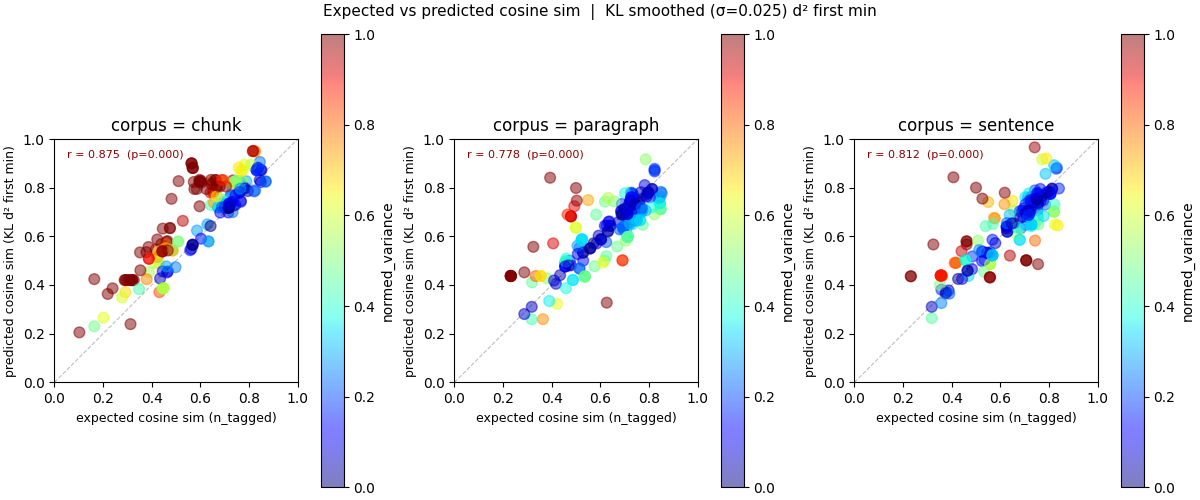

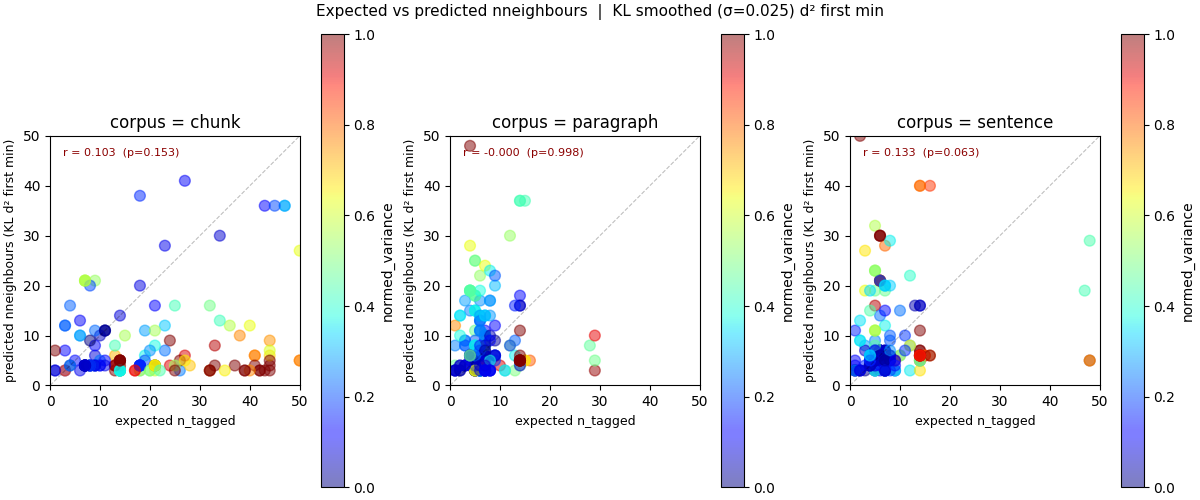

,unique_id,corpus_granularity,cs_expected,cs_predicted,min_nneighbours,n_tagged,nn_predicted,cosine_sim_std,variance,normed_variance,trivial
0,Financing Sources Require Consent | SRT NDA Ma...,chunk,0.770950,0.814381,4,18,3,0.125425,-0.043431,0.346270,True
1,Financing Sources Require Consent | SRT NDA Ma...,paragraph,0.758641,0.735997,3,7,9,0.251397,0.022644,0.090073,False
2,Financing Sources Require Consent | SRT NDA Ma...,sentence,0.731357,0.760625,3,7,3,0.163611,-0.029268,0.178887,True
3,Financing Sources Require Consent | ACM - Eide...,chunk,0.731359,0.787732,4,19,6,0.154886,-0.056373,0.363967,False
4,Financing Sources Require Consent | ACM - Eide...,paragraph,0.732154,0.770848,3,7,3,0.269192,-0.038694,0.143741,True
...,...,...,...,...,...,...,...,...,...,...,...
580,Non Solicitation Present | Project_Yellowstone...,paragraph,0.711286,0.597276,3,4,19,0.252747,0.114010,0.451082,False
581,Non Solicitation Present | Project_Yellowstone...,sentence,0.716244,0.688400,4,4,5,0.175950,0.027844,0.158252,False
582,Non Solicitation Present | Project Waypoint - ...,chunk,0.447814,0.387015,4,7,21,0.107361,0.060799,0.566305,False
583,Non Solicitation Present | Project Waypoint - ...,paragraph,0.535662,0.435066,4,4,6,0.211888,0.100595,0.474757,False


In [22]:
from scipy.signal import argrelmin, argrelmax
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr

KL_N_GRID = 100
KL_SMOOTH_SIGMA = 0.025

results = []
df = df0.query("query_granularity=='paragraph'")
for uid in df["unique_id"].unique():
    for cg in ["chunk", "paragraph", "sentence"]:
        grp = (
            df[(df["unique_id"] == uid) & (df["corpus_granularity"] == cg)]
            .dropna(subset=["cosine_similarity", "kl_divergence", "nneighbours"])
            
            .sort_values("cosine_similarity")
            .reset_index(drop=True)
        )
        if len(grp) < 5:
            continue

        n_tagged_vals = grp["n_tagged"].dropna().unique()
        n_tagged_val = n_tagged_vals[0] if len(n_tagged_vals) > 0 else np.nan

        if not np.isnan(n_tagged_val):
            idx = (grp["nneighbours"] - n_tagged_val).abs().idxmin()
            cs_expected = grp.loc[idx, "cosine_similarity"]
        else:
            cs_expected = np.nan

        cs_raw = grp["cosine_similarity"].values
        kl_raw = grp["kl_divergence"].values

        cs_grid = np.linspace(cs_raw.min(), cs_raw.max(), KL_N_GRID)
        grid_step = cs_grid[1] - cs_grid[0]

        kl_interp = interp1d(cs_raw, kl_raw, kind="linear", fill_value="extrapolate")(cs_grid)
        sigma_bins = KL_SMOOTH_SIGMA / grid_step
        kl_smooth = gaussian_filter1d(kl_interp, sigma=sigma_bins, mode="nearest")

        d1 = np.gradient(kl_smooth, cs_grid)
        d2 = abs(np.gradient(d1, cs_grid))

        minima = argrelmax(d2, order=10)[0]
        cs_predicted = cs_grid[minima[-1]] if len(minima) > 0 else np.nan
        #w1_h0s = list(grp[grp.cosine_similarity>=cs_predicted].sort_values(by="cosine_similarity").w1_h0)
        #w1_h0_pred = w1_h0s[-1] if w1_h0s else grp.w1_h0.iloc[0]
        nn_pred = list(grp[grp.cosine_similarity >= cs_predicted].sort_values(by="cosine_similarity").nneighbours)
        nn_predicted = nn_pred[0] if nn_pred else grp.nneighbours.iloc[-1]
        
        bins = np.linspace(grp.cosine_similarity.min(),grp.cosine_similarity.max(),10)
        bins_ids = np.unique(np.digitize(grp.cosine_similarity, bins=bins)) - 1
        amplitude = np.std(bins[bins_ids])

        #min_max = max(abs(grp.cosine_similarity.diff().dropna()))
        
        
        results.append({
            "unique_id": uid,
            "corpus_granularity": cg,
            "cs_expected":  cs_expected,
            "cs_predicted": cs_predicted,
            "min_nneighbours": grp.nneighbours.iloc[-1],
            "n_tagged": n_tagged_val,
            "nn_predicted": nn_predicted,
            "cosine_sim_std":amplitude,
            "variance": cs_expected - cs_predicted,
            "normed_variance": abs(cs_expected - cs_predicted)/amplitude,
            "trivial": nn_predicted <= grp.nneighbours.iloc[-1]
        })

df_results = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(12, 5), constrained_layout=True)

for ax, cg in zip(axes, ["chunk", "paragraph","sentence"]):
    sub = df_results[df_results["corpus_granularity"] == cg].dropna(subset=["cs_expected", "cs_predicted"])
    #sub = sub[sub.trivial]

    sc = ax.scatter(sub["cs_expected"], sub["cs_predicted"],c=sub["normed_variance"],cmap="jet",vmin=0,vmax=1.0, alpha=0.5, s=60)
    fig.colorbar(sc, ax=ax, label="normed_variance")

    lims = [0, 200]
    ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.25)

    # for _, row in sub.iterrows():
    #     ax.annotate(row["unique_id"].split(" | ")[0], (row["cs_expected"], row["cs_predicted"]),
    #                 fontsize=6, textcoords="offset points", xytext=(4, 2))

    if len(sub) >= 2:
        r, pval = pearsonr(sub["cs_expected"], sub["cs_predicted"])
        ax.text(0.05, 0.92, f"r = {r:.3f}  (p={pval:.3f})", transform=ax.transAxes,
                fontsize=8, color="darkred")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("expected cosine sim (n_tagged)", fontsize=9)
    ax.set_ylabel("predicted cosine sim (KL d² first min)", fontsize=9)
    ax.set_title(f"corpus = {cg}")
    ax.set_aspect("equal")

plt.suptitle(
    f"Expected vs predicted cosine sim  |  KL smoothed (σ={KL_SMOOTH_SIGMA}) d² first min",
    fontsize=11
)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 5), constrained_layout=True)

for ax, cg in zip(axes, ["chunk", "paragraph","sentence"]):
    sub = df_results[df_results["corpus_granularity"] == cg].dropna(subset=["n_tagged", "nn_predicted"])
    #sub = sub[sub.trivial]

    sc = ax.scatter(sub["n_tagged"], sub["nn_predicted"],c=sub["normed_variance"],cmap="jet",vmin=0,vmax=1.0, alpha=0.5, s=60)
    fig.colorbar(sc, ax=ax, label="normed_variance")

    lims = [0, 200]
    ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.25)

    # for _, row in sub.iterrows():
    #     ax.annotate(row["unique_id"].split(" | ")[0], (row["cs_expected"], row["cs_predicted"]),
    #                 fontsize=6, textcoords="offset points", xytext=(4, 2))

    if len(sub) >= 2:
        r, pval = pearsonr(sub["n_tagged"], sub["nn_predicted"])
        ax.text(0.05, 0.92, f"r = {r:.3f}  (p={pval:.3f})", transform=ax.transAxes,
                fontsize=8, color="darkred")

    ax.set_xlim(0, 50)
    ax.set_ylim(0, 50)
    ax.set_xlabel("expected n_tagged", fontsize=9)
    ax.set_ylabel("predicted nneighbours (KL d² first min)", fontsize=9)
    ax.set_title(f"corpus = {cg}")
    ax.set_aspect("equal")

plt.suptitle(
    f"Expected vs predicted nneighbours  |  KL smoothed (σ={KL_SMOOTH_SIGMA}) d² first min",
    fontsize=11
)
plt.show()

df_results


In [ ]:
df_results["nneigh_offset"] = (df_results["n_tagged"] - df_results["nn_predicted"])/df_results["n_tagged"]
#df_res_p = df_results.query("corpus_granularity=='chunk'")
plt.figure()

sns.kdeplot(data=df_results, x="nneigh_offset",y="normed_variance", hue="corpus_granularity")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
sns.histplot(df_results[["corpus_granularity","normed_variance"]],x="normed_variance", hue="corpus_granularity",multiple="stack", ax=axes[0], bins=np.arange(0,5,0.1))
sns.histplot(df_results[["corpus_granularity","variance"]],x="variance", hue="corpus_granularity",multiple="stack", ax=axes[1], bins=np.arange(0,.5,0.01))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
sns.histplot(df_results[["corpus_granularity","cosine_sim_std"]],x="cosine_sim_std", hue="corpus_granularity",multiple="layer", ax=axes[0], bins=np.arange(0,1,0.01))


In [ ]:
from scipy.signal import argrelmin,argrelmax
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr
import itertools

GRID_SIZES   = [100, 250, 500, 1000, 2000]
SIGMA_VALUES = np.logspace(-2, 0, 20)  # 0.01 → 1.0 in cosine_sim units

def _pearson_for_params(n_grid, sigma, grp_data):
    """Return (r_chunk, r_paragraph) for given params across all uid groups."""
    results = []
    for uid, cg, grp in grp_data:
        cs_raw = grp["cosine_similarity"].values
        kl_raw = grp["kl_divergence"].values

        cs_grid = np.linspace(cs_raw.min(), cs_raw.max(), n_grid)
        grid_step = cs_grid[1] - cs_grid[0]
        if grid_step == 0:
            continue

        kl_interp = interp1d(cs_raw, kl_raw, kind="linear", fill_value="extrapolate")(cs_grid)
        sigma_bins = sigma / grid_step
        kl_smooth = gaussian_filter1d(kl_interp, sigma=sigma_bins, mode="nearest")

        d1 = np.gradient(kl_smooth, cs_grid)
        d2 = np.gradient(d1, cs_grid)
        minima = argrelmax(d2, order=10)[0]
        cs_predicted = cs_grid[minima[-1]] if len(minima) > 0 else np.nan
        
        nn_pred = list(grp[grp.cosine_similarity <= cs_predicted].sort_values(by="nneighbours").nneighbours)
        cs_predicted = nn_pred[0] if nn_pred else grp.nneighbours.iloc[0]

        n_tagged_vals = grp["n_tagged"].dropna().unique()
        n_tagged_val = n_tagged_vals[0] if len(n_tagged_vals) > 0 else np.nan
        if not np.isnan(n_tagged_val):
            idx = (grp["nneighbours"] - n_tagged_val).abs().idxmin()
            cs_expected = grp.loc[idx, "nneighbours"]
        else:
            cs_expected = np.nan



        results.append({"cg": cg, "cs_expected": cs_expected, "cs_predicted": cs_predicted})

    out = {}
    for cg in ["chunk", "paragraph"]:
        sub = [(r["cs_expected"], r["cs_predicted"]) for r in results
               if r["cg"] == cg and not (np.isnan(r["cs_expected"]) or np.isnan(r["cs_predicted"]))]
        if len(sub) >= 2:
            x, y = zip(*sub)
            out[cg], _ = pearsonr(x, y)
        else:
            out[cg] = np.nan
    return out["chunk"], out["paragraph"]

# Pre-filter groups once
grp_data = []
for uid in df["unique_id"].unique():
    for cg in ["chunk", "paragraph"]:
        grp = (
            df[(df["unique_id"] == uid) & (df["corpus_granularity"] == cg)]
            .dropna(subset=["cosine_similarity", "kl_divergence", "nneighbours"])
            .sort_values("cosine_similarity")
            .reset_index(drop=True)
        )
        if len(grp) >= 5:
            grp_data.append((uid, cg, grp))

# Grid search
search_results = []
for n_grid, sigma in itertools.product(GRID_SIZES, SIGMA_VALUES):
    r_chunk, r_para = _pearson_for_params(n_grid, sigma, grp_data)
    search_results.append({
        "n_grid": n_grid, "sigma": sigma,
        "r_chunk": r_chunk, "r_paragraph": r_para,
        "r_mean": np.nanmean([r_chunk, r_para]),
    })

df_search = pd.DataFrame(search_results)
best = df_search.loc[df_search["r_mean"].idxmax()]
print(f"Best  n_grid={int(best.n_grid)}  sigma={best.sigma:.4f}  "
      f"r_chunk={best.r_chunk:.3f}  r_para={best.r_paragraph:.3f}  r_mean={best.r_mean:.3f}")

# ── heatmaps ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

for ax, col, title in zip(axes, ["r_chunk", "r_paragraph", "r_mean"],
                          ["Pearson r — chunk", "Pearson r — paragraph", "Pearson r — mean"]):
    pivot = df_search.pivot_table(index="sigma", columns="n_grid", values=col)
    im = ax.pcolormesh(
        pivot.columns, pivot.index, pivot.values,
        shading="auto", cmap="RdYlGn", vmin=-1, vmax=1
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("n_grid", fontsize=9)
    ax.set_ylabel("sigma (cosine_sim units)", fontsize=9)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax)

    # mark best
    ax.scatter([best.n_grid], [best.sigma], marker="*", color="black", s=120, zorder=5)

plt.suptitle("Pearson r grid search  (cosine_sim prediction)", fontsize=11)
plt.show()

df_search


In [ ]:
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from scipy.signal import argrelmin, argrelmax

# Recompute intermediates for all (uid, cg) groups - cosine_sim axis
KL_N_GRID = 100
KL_SMOOTH_SIGMA = 0.025

diagnostics = []

for (uid, cg), grp in df.groupby(["unique_id", "corpus_granularity"]):
    grp = grp.dropna(subset=["cosine_similarity", "kl_divergence"]).sort_values("cosine_similarity")
    if len(grp) < 4:
        continue

    cs_raw = grp["cosine_similarity"].values.astype(float)
    kl_raw = grp["kl_divergence"].values.astype(float)

    cs_grid = np.linspace(cs_raw.min(), cs_raw.max(), KL_N_GRID)
    grid_step = cs_grid[1] - cs_grid[0]

    kl_interp = interp1d(cs_raw, kl_raw, kind="linear", fill_value="extrapolate")(cs_grid)
    sigma_bins = KL_SMOOTH_SIGMA / grid_step
    kl_smooth = gaussian_filter1d(kl_interp, sigma=sigma_bins, mode="nearest")

    d1 = np.gradient(kl_smooth, cs_grid)
    d2 = np.gradient(d1, cs_grid)

    minima = argrelmax(d2, order=10)[-1]
    cs_pred = cs_grid[minima[-1]] if len(minima) > 0 else np.nan

    n_tagged_vals = grp["n_tagged"].dropna().unique()
    n_tagged_val = n_tagged_vals[0] if len(n_tagged_vals) > 0 else np.nan
    if not np.isnan(n_tagged_val):
        idx = (grp["nneighbours"] - n_tagged_val).abs().idxmin()
        cs_expected = grp.loc[idx, "cosine_similarity"]
    else:
        cs_expected = np.nan

    diagnostics.append(dict(
        uid=uid, cg=cg,
        cs_raw=cs_raw, kl_raw=kl_raw,
        cs_grid=cs_grid, kl_interp=kl_interp, kl_smooth=kl_smooth,
        d2=d2, cs_pred=cs_pred, cs_expected=cs_expected,
    ))

# ── grid layout ──────────────────────────────────────────────────────────────
diagnostics = diagnostics[:20]

NCOLS = 4
nrows_per = 2   # top: KL  /  bottom: d2
n = len(diagnostics)
ncols = min(NCOLS, n)
ngrids = int(np.ceil(n / ncols))
fig_h = ngrids * nrows_per * 2.2

fig = plt.figure(figsize=(ncols * 3.5, fig_h))
outer = fig.add_gridspec(ngrids, ncols, hspace=0.6, wspace=0.35)

for i, d in enumerate(diagnostics):
    row_g, col_g = divmod(i, ncols)
    inner = outer[row_g, col_g].subgridspec(nrows_per, 1, hspace=0.05)

    ax_kl = fig.add_subplot(inner[0])
    ax_d2 = fig.add_subplot(inner[1], sharex=ax_kl)

    # --- top: raw KL + smooth ---
    ax_kl.scatter(d["cs_raw"], d["kl_raw"], s=8, color="steelblue", alpha=0.7, zorder=3, label="raw")
    ax_kl.plot(d["cs_grid"], d["kl_interp"], color="steelblue", lw=0.8, alpha=0.4, label="interp")
    ax_kl.plot(d["cs_grid"], d["kl_smooth"], color="navy", lw=1.2, label="smooth")
    if not np.isnan(d["cs_pred"]):
        ax_kl.axvline(d["cs_pred"], color="red", lw=0.9, ls="--", label="pred")
    if not np.isnan(d["cs_expected"]):
        ax_kl.axvline(d["cs_expected"], color="green", lw=0.9, ls=":", label="exp")
    ax_kl.set_ylabel("KL", fontsize=6)
    ax_kl.tick_params(labelbottom=False, labelsize=6)
    ax_kl.set_title(f"{d['uid'].split(' | ')[0]}\n{d['cg']}", fontsize=6, pad=2)

    # --- bottom: d2 ---
    ax_d2.plot(d["cs_grid"], d["d2"], color="darkorange", lw=1.0)
    ax_d2.axhline(0, color="gray", lw=0.5, ls="--")
    if not np.isnan(d["cs_pred"]):
        ax_d2.axvline(d["cs_pred"], color="red", lw=0.9, ls="--")
    if not np.isnan(d["cs_expected"]):
        ax_d2.axvline(d["cs_expected"], color="green", lw=0.9, ls=":")
    ax_d2.set_ylabel("d²KL", fontsize=6)
    ax_d2.tick_params(labelsize=6)
    ax_d2.set_xlabel("cosine sim", fontsize=6)

# hide unused panels
for i in range(len(diagnostics), ngrids * ncols):
    row_g, col_g = divmod(i, ncols)
    fig.add_subplot(outer[row_g, col_g]).set_visible(False)

fig.suptitle(
    f"KL diagnostic (cosine_sim)  |  smooth σ={KL_SMOOTH_SIGMA}  |  red=pred, green=expected",
    fontsize=10, y=1.01
)
plt.show()


In [ ]:
from scipy.signal import argrelmin
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

KL_NN_GRID = 500       # uniform nneighbours grid points
KL_NN_SMOOTH_SIGMA = 2.0  # Gaussian sigma in nneighbours units

results_nn = []

for (uid, cg), grp in df.groupby(["unique_id", "corpus_granularity"]):
    grp = grp.dropna(subset=["nneighbours", "kl_divergence"]).sort_values("nneighbours")
    if len(grp) < 4:
        continue

    # 1. nn_expected = n_tagged directly (n_tagged is already in nneighbours units)
    n_tagged_vals = grp["n_tagged"].dropna().unique()
    n_tagged_val = n_tagged_vals[0] if len(n_tagged_vals) > 0 else np.nan
    nn_expected = float(n_tagged_val) if not np.isnan(n_tagged_val) else np.nan

    # 2. interpolate KL onto uniform nneighbours grid, smooth, then derive
    nn_raw = grp["nneighbours"].values.astype(float)
    kl_raw = grp["kl_divergence"].values.astype(float)

    nn_grid = np.linspace(nn_raw.min(), nn_raw.max(), KL_NN_GRID)
    grid_step = nn_grid[1] - nn_grid[0]

    kl_interp = interp1d(nn_raw, kl_raw, kind="linear", fill_value="extrapolate")(nn_grid)
    sigma_bins = KL_NN_SMOOTH_SIGMA / grid_step
    kl_smooth = gaussian_filter1d(kl_interp, sigma=sigma_bins, mode="nearest")

    d1 = np.gradient(kl_smooth, nn_grid)
    d2 = np.gradient(d1, nn_grid)

    minima = argrelmin(d2, order=10)[0]
    nn_predicted = nn_grid[minima[0]] if len(minima) > 0 else min(grp.nneighbours)

    results_nn.append({
        "unique_id": uid,
        "corpus_granularity": cg,
        "nn_expected": nn_expected,
        "nn_predicted": nn_predicted,
        "n_tagged": n_tagged_val,
    })

df_results_nn = pd.DataFrame(results_nn)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for ax, cg in zip(axes, ["chunk", "paragraph"]):
    sub = df_results_nn[df_results_nn["corpus_granularity"] == cg].dropna(subset=["nn_expected", "nn_predicted"])

    ax.scatter(sub["nn_expected"], sub["nn_predicted"], alpha=0.8, s=60)

    lims = [0, sub[["nn_expected", "nn_predicted"]].max().max() * 1.05]
    ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5)

    for _, row in sub.iterrows():
        ax.annotate(row["unique_id"].split(" | ")[0], (row["nn_expected"], row["nn_predicted"]),
                    fontsize=6, textcoords="offset points", xytext=(4, 2))

    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("expected nneighbours (n_tagged)", fontsize=9)
    ax.set_ylabel("predicted nneighbours (KL d² first min)", fontsize=9)
    ax.set_title(f"corpus = {cg}")
    ax.set_aspect("equal")

plt.suptitle(
    f"Expected vs predicted nneighbours  |  KL smoothed (σ={KL_NN_SMOOTH_SIGMA}) d² first min",
    fontsize=11
)
plt.show()

df_results_nn


In [20]:
# XGBoost cutoff predictor with Optuna hyperparameter optimisation
# Features: w1_h0, kl_divergence, h0_entropy, cosine_similarity, depsilon + per-group diffs
# Label: 1 if nneighbours <= n_tagged (inside cutoff), 0 if above
# Error metric: |nn_pred - n_tagged|  (MAE in nneighbours units)

import optuna
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import RobustScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)

FEATURES = ["w1_h0", "kl_divergence", "h0_entropy", "cross_entropy"]
_BASE_COLS = ["w1_h0", "kl_divergence", "h0_entropy", "cross_entropy"]
_KEEP_COLS = _BASE_COLS + ["nneighbours", "n_tagged", "unique_id", "corpus_granularity"]


def _cs_amplitude(cs_vals, n_bins=10):
    bins = np.linspace(cs_vals.min(), cs_vals.max(), n_bins)
    bins_ids = np.clip(np.unique(np.digitize(cs_vals, bins=bins)) - 1, 0, len(bins) - 1)
    return np.std(bins[bins_ids])


def _add_diff_features(sub):
    """Add per-group (unique_id, corpus_granularity) diffs of h0_entropy and w1_h0 sorted by nneighbours."""
    sub = sub.copy()
    sub["diff_h0_entropy"] = np.nan
    sub["diff_w1_h0"] = np.nan
    for _, grp_idx in sub.groupby(["unique_id", "corpus_granularity"]).groups.items():
        grp = sub.loc[grp_idx].sort_values("nneighbours")
        sub.loc[grp.index, "diff_h0_entropy"] = grp["h0_entropy"].diff().values
        sub.loc[grp.index, "diff_w1_h0"]      = grp["w1_h0"].diff().values
    return sub


def build_xgb_dataset(df, cg=None):
    keep = [c for c in _KEEP_COLS if c in df.columns]
    sub = df[keep].copy().reset_index(drop=True)
    if cg is not None:
        sub = sub[sub["corpus_granularity"] == cg].reset_index(drop=True)
    sub = sub.dropna(subset=_BASE_COLS + ["nneighbours", "n_tagged"]).reset_index(drop=True)
    for col in _BASE_COLS:
        sub[col] = sub[col].replace([np.inf, -np.inf], np.nan)
    sub = sub.dropna(subset=_BASE_COLS).reset_index(drop=True)
    sub = _add_diff_features(sub)
    sub["in_cutoff"] = (sub["nneighbours"] <= sub["n_tagged"]).astype(int)
    # diff is NaN for the first row of each group; fill with 0
    sub[["diff_h0_entropy", "diff_w1_h0"]] = sub[["diff_h0_entropy", "diff_w1_h0"]].fillna(0.0)
    return sub


def _group_mae(df_fold, pred_col="in_cutoff_pred"):
    errors = []
    for (uid, cg), grp in df_fold.groupby(["unique_id", "corpus_granularity"]):
        grp_s = grp.sort_values("nneighbours").reset_index(drop=True)
        inside = grp_s[grp_s[pred_col] == 1]
        nn_pred = inside["nneighbours"].max() if not inside.empty else grp_s["nneighbours"].min()
        nn_true = grp_s["n_tagged"].iloc[0]
        errors.append(abs(nn_pred - nn_true))
    return float(np.mean(errors)) if errors else np.inf


def optimise_xgb_cutoff(df, n_trials=60, n_splits=4, random_state=42):
    dataset = build_xgb_dataset(df)
    X = dataset[FEATURES].values
    y = dataset["in_cutoff"].values
    groups = dataset["unique_id"].values

    scaler = RobustScaler()
    X_s = scaler.fit_transform(X)

    gkf = GroupKFold(n_splits=n_splits)
    pos_weight = max((y == 0).sum() / max((y == 1).sum(), 1), 1.0)

    def objective(trial):
        params = dict(
            n_estimators     = trial.suggest_int("n_estimators", 100, 600),
            max_depth        = trial.suggest_int("max_depth", 2, 7),
            learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            subsample        = trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree = trial.suggest_float("colsample_bytree", 0.4, 1.0),
            min_child_weight = trial.suggest_int("min_child_weight", 1, 20),
            gamma            = trial.suggest_float("gamma", 0.0, 5.0),
            reg_alpha        = trial.suggest_float("reg_alpha", 0.0, 2.0),
            reg_lambda       = trial.suggest_float("reg_lambda", 0.5, 5.0),
            scale_pos_weight = pos_weight,
            eval_metric="logloss", verbosity=0,
        )
        fold_errors = []
        for train_idx, test_idx in gkf.split(X_s, y, groups=groups):
            model = xgb.XGBClassifier(**params, random_state=random_state)
            model.fit(X_s[train_idx], y[train_idx])
            df_fold = dataset.iloc[test_idx].reset_index(drop=True).copy()
            df_fold["in_cutoff_pred"] = model.predict(X_s[test_idx])
            fold_errors.append(_group_mae(df_fold))
        return float(np.mean(fold_errors))

    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=random_state))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"Best MAE: {study.best_value:.4f}")
    print("Best params:", study.best_params)
    return study.best_params, scaler, dataset


def train_xgb_cutoff(df, best_params, test_size=0.25, random_state=42):
    dataset = build_xgb_dataset(df)
    X = dataset[FEATURES].values
    y = dataset["in_cutoff"].values
    groups = dataset["unique_id"].values

    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(X, y, groups=groups))

    scaler = RobustScaler()
    X_train_s = scaler.fit_transform(X[train_idx])
    X_test_s  = scaler.transform(X[test_idx])
    y_train   = y[train_idx]
    df_test   = dataset.iloc[test_idx].reset_index(drop=True)

    pos_weight = max((y_train == 0).sum() / max((y_train == 1).sum(), 1), 1.0)
    model = xgb.XGBClassifier(
        **best_params,
        scale_pos_weight=pos_weight,
        eval_metric="logloss",
        random_state=random_state,
        verbosity=0,
    )
    model.fit(X_train_s, y_train)
    df_test["in_cutoff_pred"]  = model.predict(X_test_s)
    df_test["in_cutoff_proba"] = model.predict_proba(X_test_s)[:, 1]
    return model, scaler, df_test


def evaluate_cutoff_predictions(df_test):
    results = []
    for (uid, cg), grp in df_test.groupby(["unique_id", "corpus_granularity"]):
        grp_sorted = grp.sort_values("nneighbours").reset_index(drop=True)
        inside = grp_sorted[grp_sorted["in_cutoff_pred"] == 1]
        nn_pred = inside["nneighbours"].max() if not inside.empty else grp_sorted["nneighbours"].min()
        nn_true = grp_sorted["n_tagged"].iloc[0]
        #cs_vals = grp_sorted["cosine_similarity"].dropna().values
        #amplitude = _cs_amplitude(cs_vals) if len(cs_vals) >= 2 else np.nan
        results.append({
            "unique_id": uid, "corpus_granularity": cg,
            "nn_predicted": nn_pred, "n_tagged": nn_true,
            "abs_error": abs(nn_pred - nn_true), "cs_amplitude": 1.0,
        })
    return pd.DataFrame(results)


=== corpus_granularity = 'paragraph' (29463 rows) ===


  0%|          | 0/60 [00:00<?, ?it/s]

Best MAE: 3.7653
Best params: {'n_estimators': 502, 'max_depth': 7, 'learning_rate': 0.12643181836469364, 'subsample': 0.7678445600256709, 'colsample_bytree': 0.990687220210983, 'min_child_weight': 1, 'gamma': 0.024620228082835482, 'reg_alpha': 1.5691262869256641, 'reg_lambda': 0.9762035607629709}
=== corpus_granularity = 'chunk' (33472 rows) ===


  0%|          | 0/60 [00:00<?, ?it/s]

Best MAE: 17.0504
Best params: {'n_estimators': 350, 'max_depth': 6, 'learning_rate': 0.2952470891234149, 'subsample': 0.6431690300533466, 'colsample_bytree': 0.8429062285195869, 'min_child_weight': 14, 'gamma': 0.37894278749495675, 'reg_alpha': 1.1313636957066036, 'reg_lambda': 2.3208211083598576}
=== Error summary (MAE in nneighbours units) ===
                    count   mean    std  min  25%   50%   75%   max
corpus_granularity                                                 
chunk                49.0  16.59  15.78  0.0  4.0  12.0  21.0  70.0
paragraph            49.0   4.51   4.86  0.0  1.0   3.0   6.0  21.0


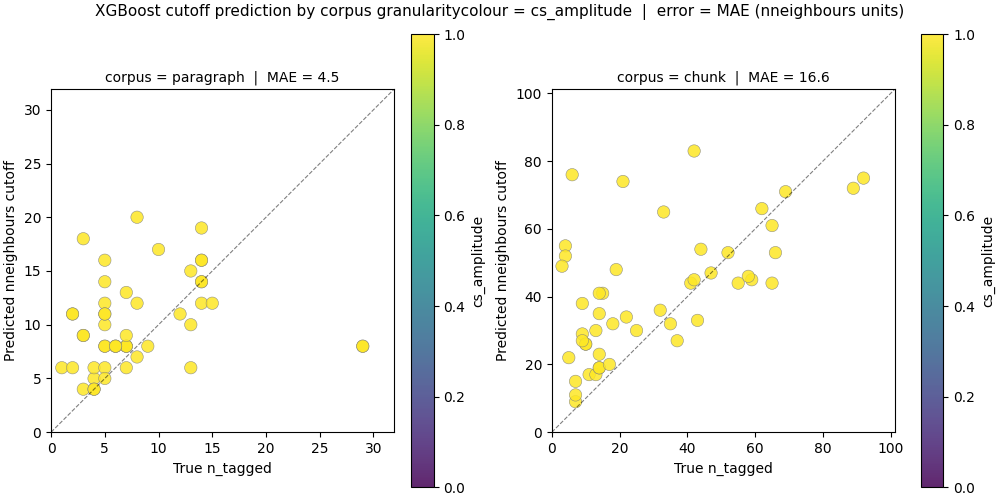

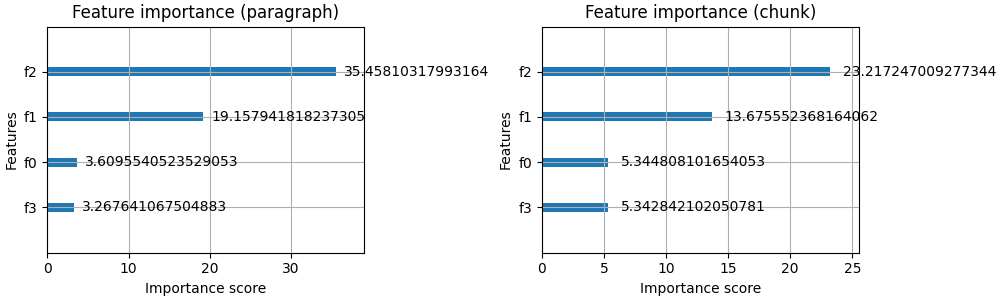

,unique_id,corpus_granularity,nn_predicted,n_tagged,abs_error,cs_amplitude
0,CI Definition Includes Third Party Info | Proj...,paragraph,10,5,5,1.0
1,CI Definition Industry Specific Terms | SRT ND...,paragraph,4,3,1,1.0
2,CI Definition Scope | Project Greenlight - KHL...,paragraph,8,29,21,1.0
3,CI Definition Scope | Project_Yellowstone_-_On...,paragraph,8,29,21,1.0
4,CI Definition Software Specific | Project Gree...,paragraph,6,1,5,1.0
...,...,...,...,...,...,...
93,Return Destruction Required | ACM - Eide Baill...,chunk,74,21,53,1.0
94,Securities Provisions Present | Project Greenl...,chunk,49,3,46,1.0
95,Title | YellowstoneB2B-OTPP-03-06-2026 - Antar...,chunk,53,52,1,1.0
96,Venue Exclusive | SRT NDA Master Template (OTP...,chunk,30,25,5,1.0


In [21]:
# Optimise hyperparameters separately for paragraph and chunk corpus granularity

data_para = df0.query("query_granularity=='paragraph'")

def _run_xgb_for_cg(df, cg, n_trials=60):
    data_cg = df[df["corpus_granularity"] == cg].reset_index(drop=True)
    print(f"=== corpus_granularity = {cg!r} ({len(data_cg)} rows) ===")
    best_params, _, _ = optimise_xgb_cutoff(data_cg, n_trials=n_trials)
    model, scaler, df_test = train_xgb_cutoff(data_cg, best_params)
    df_eval = evaluate_cutoff_predictions(df_test)
    return model, scaler, df_eval

xgb_model_para, xgb_scaler_para, df_eval_para = _run_xgb_for_cg(data_para, "paragraph")
xgb_model_chunk, xgb_scaler_chunk, df_eval_chunk = _run_xgb_for_cg(data_para, "chunk")

# ── comparison table ──────────────────────────────────────────────────────────
df_eval_para["corpus_granularity"]  = "paragraph"
df_eval_chunk["corpus_granularity"] = "chunk"
df_eval_all = pd.concat([df_eval_para, df_eval_chunk], ignore_index=True)

print("=== Error summary (MAE in nneighbours units) ===")
print(df_eval_all.groupby("corpus_granularity")["abs_error"].describe().round(2))

# ── scatter plots side by side ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
for ax, (cg, df_eval, model) in zip(axes, [
    ("paragraph", df_eval_para, xgb_model_para),
    ("chunk",     df_eval_chunk, xgb_model_chunk),
]):
    sub = df_eval.dropna(subset=["n_tagged", "nn_predicted", "cs_amplitude"])
    lim = max(sub[["n_tagged", "nn_predicted"]].max().max() * 1.1, 5)
    sc = ax.scatter(
        sub["n_tagged"], sub["nn_predicted"],
        c=sub["cs_amplitude"], cmap="viridis",
        vmin=0, vmax=sub["cs_amplitude"].quantile(0.95),
        s=80, alpha=0.85, edgecolors="grey", linewidths=0.4,
    )
    fig.colorbar(sc, ax=ax, label="cs_amplitude")
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.5)
    ax.set_xlabel("True n_tagged", fontsize=10)
    ax.set_ylabel("Predicted nneighbours cutoff", fontsize=10)
    ax.set_title(f"corpus = {cg}  |  MAE = {sub['abs_error'].mean():.1f}", fontsize=10)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")

plt.suptitle( "XGBoost cutoff prediction by corpus granularity"
    "colour = cs_amplitude  |  error = MAE (nneighbours units)",
    fontsize=11,
)
plt.show()

# ── feature importances side by side ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
for ax, (cg, model) in zip(axes, [("paragraph", xgb_model_para), ("chunk", xgb_model_chunk)]):
    xgb.plot_importance(model, ax=ax, importance_type="gain", title=f"Feature importance ({cg})")
plt.show()

df_eval_all


In [ ]:
df0["in_recall"] = df0["nneighbours"]<=df0["n_tagged"]


<Axes: xlabel='cross_entropy', ylabel='w1_h0'>

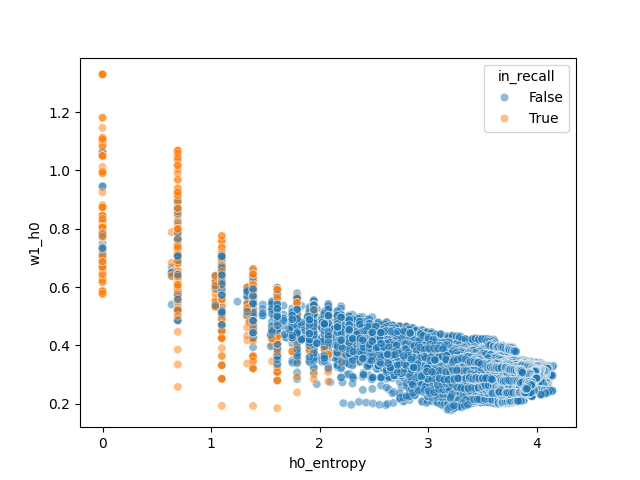

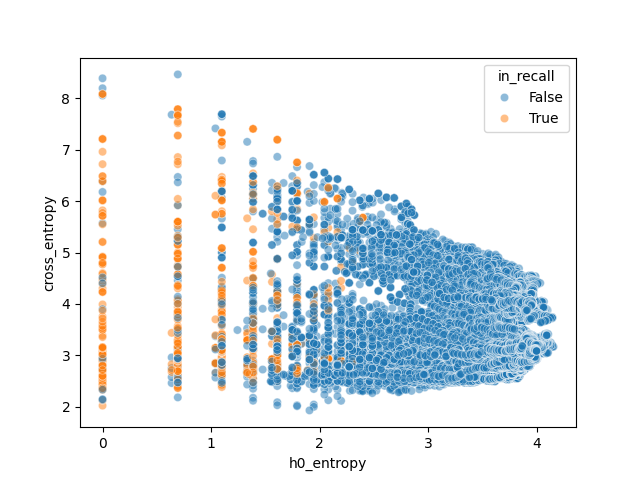

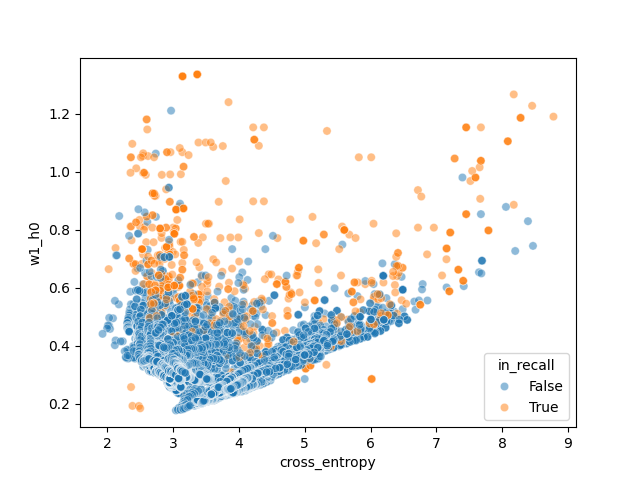

In [39]:
plt.figure()
sns.scatterplot(data=df0.query("query_granularity=='paragraph' & corpus_granularity=='paragraph'").reset_index(drop=True), x="h0_entropy",y="w1_h0", hue="in_recall",alpha=0.5)
plt.figure()
sns.scatterplot(data=df0.query("query_granularity=='paragraph' & corpus_granularity=='paragraph'").reset_index(drop=True), x="h0_entropy",y="cross_entropy", hue="in_recall",alpha=0.5)
plt.figure()
sns.scatterplot(data=df0.query("query_granularity=='paragraph' & corpus_granularity=='paragraph'").reset_index(drop=True), x="cross_entropy",y="w1_h0", hue="in_recall",alpha=0.5)

In [51]:
# Random Forest cutoff predictor with Optuna hyperparameter optimisation
# Same features / label / error metric as XGBoost above.
# Outputs class probabilities → transition-band width used as uncertainty.

from sklearn.ensemble import RandomForestClassifier

def optimise_rf_cutoff(df, n_trials=60, n_splits=4, random_state=42):
    dataset = build_xgb_dataset(df)          # reuse same dataset builder
    X       = dataset[FEATURES].values
    y       = dataset["in_cutoff"].values
    groups  = dataset["unique_id"].values

    scaler  = RobustScaler()
    X_s     = scaler.fit_transform(X)
    gkf     = GroupKFold(n_splits=n_splits)

    def objective(trial):
        params = dict(
            n_estimators = trial.suggest_int("n_estimators",  50, 600),
            max_depth    = trial.suggest_int("max_depth",      3,  20),
            min_samples_split = trial.suggest_int("min_samples_split", 2, 20),
            min_samples_leaf  = trial.suggest_int("min_samples_leaf",  1, 10),
            max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            class_weight = "balanced",
            random_state = random_state,
            n_jobs       = -1,
        )
        fold_errors = []
        for tr, va in gkf.split(X_s, y, groups=groups):
            m = RandomForestClassifier(**params)
            m.fit(X_s[tr], y[tr])
            df_fold = dataset.iloc[va].reset_index(drop=True).copy()
            df_fold["in_cutoff_pred"] = m.predict(X_s[va])
            fold_errors.append(_group_mae(df_fold))   # reuse XGB MAE helper
        return float(np.mean(fold_errors))

    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=random_state))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"Best MAE: {study.best_value:.4f}")
    print("Best params:", study.best_params)
    return study.best_params, scaler, dataset


def train_rf_cutoff(df, best_params, test_size=0.25, random_state=42):
    dataset = build_xgb_dataset(df)
    X       = dataset[FEATURES].values
    y       = dataset["in_cutoff"].values
    groups  = dataset["unique_id"].values

    tr, te = next(GroupShuffleSplit(n_splits=1, test_size=test_size,
                                    random_state=random_state).split(X, y, groups=groups))
    scaler    = RobustScaler()
    X_tr      = scaler.fit_transform(X[tr])
    X_te      = scaler.transform(X[te])

    model = RandomForestClassifier(
        **best_params, class_weight="balanced",
        random_state=random_state, n_jobs=-1,
    )
    model.fit(X_tr, y[tr])

    df_test = dataset.iloc[te].reset_index(drop=True).copy()
    df_test["in_cutoff_pred"]  = model.predict(X_te)
    df_test["in_cutoff_proba"] = model.predict_proba(X_te)[:, 1]
    return model, scaler, df_test


def evaluate_rf_predictions(df_test):
    """Same logic as evaluate_cutoff_predictions; adds transition_band uncertainty."""
    results = []
    for (uid, cg), grp in df_test.groupby(["unique_id", "corpus_granularity"]):
        grp_s  = grp.sort_values("nneighbours").reset_index(drop=True)
        inside = grp_s[grp_s["in_cutoff_pred"] == 1]
        nn_pred = inside["nneighbours"].max() if not inside.empty else grp_s["nneighbours"].min()
        nn_true = grp_s["n_tagged"].iloc[0]
        cs_vals = grp_s["cosine_similarity"].dropna().values
        amplitude = _cs_amplitude(cs_vals) if len(cs_vals) >= 2 else np.nan

        # transition band: nneighbours range where 0.3 < proba < 0.7
        band = grp_s[(grp_s["in_cutoff_proba"] > 0.3) & (grp_s["in_cutoff_proba"] < 0.7)]
        uncertainty = band["nneighbours"].max() - band["nneighbours"].min() if not band.empty else 0.0

        results.append({
            "unique_id": uid, "corpus_granularity": cg,
            "nn_predicted": nn_pred, "n_tagged": nn_true,
            "abs_error": abs(nn_pred - nn_true),
            "cs_amplitude": amplitude,
            "uncertainty": uncertainty,
        })
    return pd.DataFrame(results)


  0%|          | 0/60 [00:00<?, ?it/s]

Best MAE: 5.1470
Best params: {'n_estimators': 518, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}

=== RF Error summary (MAE in nneighbours units) ===
                    count   mean    std  min  25%  50%   75%   max
corpus_granularity                                                
chunk                49.0  10.80  12.13  0.0  2.0  8.0  15.0  50.0
paragraph            49.0   3.49   4.85  0.0  1.0  2.0   4.0  21.0
sentence             49.0   4.27   8.05  0.0  1.0  2.0   4.0  41.0


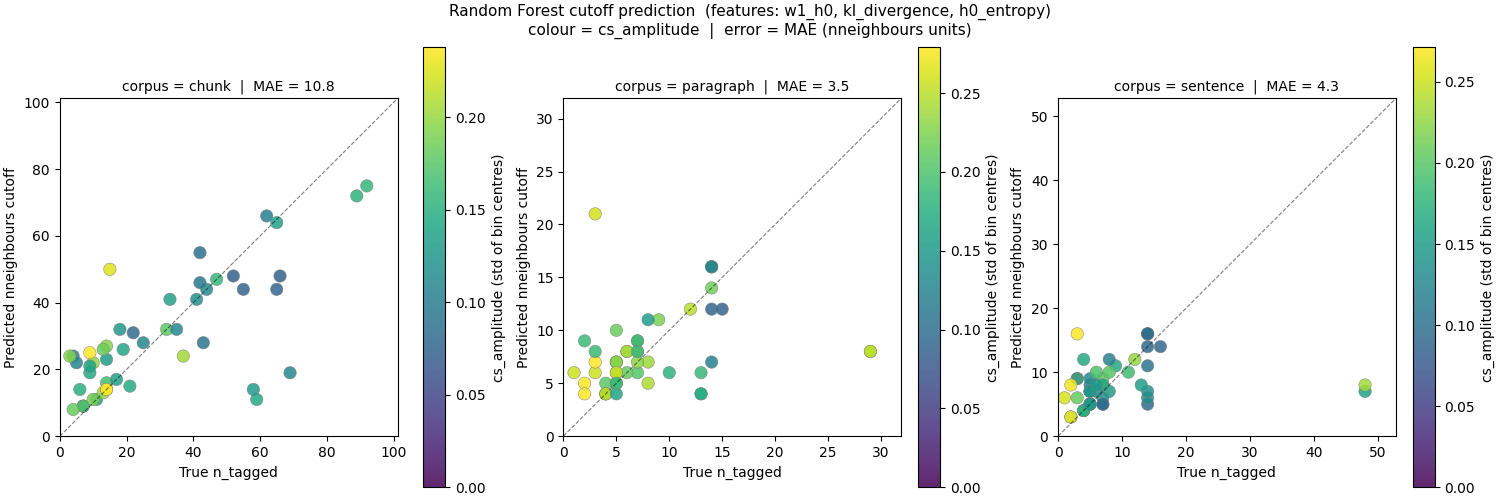

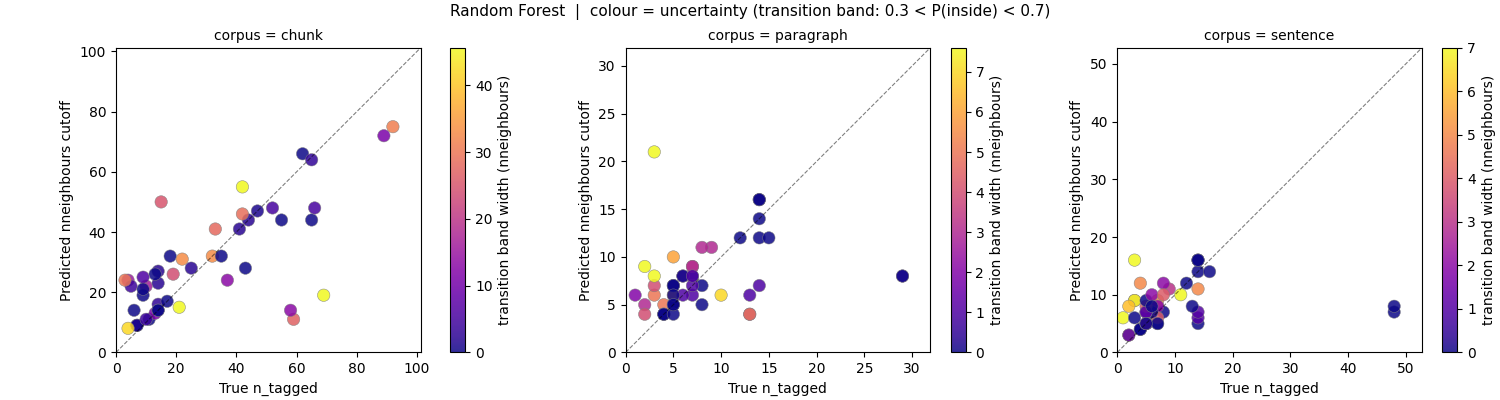

ValueError: Length of values (6) does not match length of index (5)

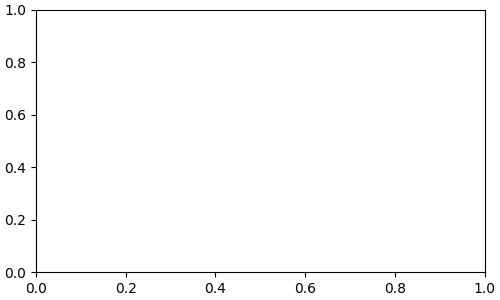

In [52]:
# Random Forest test run

data_para = df0.query("query_granularity=='paragraph'")

rf_best, _, _ = optimise_rf_cutoff(data_para, n_trials=60)
rf_model, rf_scaler, rf_test = train_rf_cutoff(data_para, rf_best)
df_rf_eval = evaluate_rf_predictions(rf_test)

print("\n=== RF Error summary (MAE in nneighbours units) ===")
print(df_rf_eval.groupby("corpus_granularity")["abs_error"].describe().round(2))

cgs = sorted(df_rf_eval["corpus_granularity"].unique())
fig, axes = plt.subplots(1, len(cgs), figsize=(5 * len(cgs), 5), constrained_layout=True)
if len(cgs) == 1:
    axes = [axes]

for ax, cg in zip(axes, cgs):
    sub = df_rf_eval[df_rf_eval["corpus_granularity"] == cg].dropna(
        subset=["n_tagged", "nn_predicted", "cs_amplitude"])
    lim = max(sub[["n_tagged", "nn_predicted"]].max().max() * 1.1, 5)

    sc = ax.scatter(
        sub["n_tagged"], sub["nn_predicted"],
        c=sub["cs_amplitude"], cmap="viridis",
        vmin=0, vmax=sub["cs_amplitude"].quantile(0.95),
        s=80, alpha=0.85, edgecolors="grey", linewidths=0.4,
    )
    fig.colorbar(sc, ax=ax, label="cs_amplitude (std of bin centres)")
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.5)
    ax.set_xlabel("True n_tagged", fontsize=10)
    ax.set_ylabel("Predicted nneighbours cutoff", fontsize=10)
    ax.set_title(f"corpus = {cg}  |  MAE = {sub['abs_error'].mean():.1f}", fontsize=10)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")

plt.suptitle(
    "Random Forest cutoff prediction  (features: w1_h0, kl_divergence, h0_entropy)\n"
    "colour = cs_amplitude  |  error = MAE (nneighbours units)",
    fontsize=11,
)
plt.show()

# ── uncertainty: transition band width ───────────────────────────────────────
fig2, axes2 = plt.subplots(1, len(cgs), figsize=(5 * len(cgs), 4), constrained_layout=True)
if len(cgs) == 1:
    axes2 = [axes2]

for ax, cg in zip(axes2, cgs):
    sub = df_rf_eval[df_rf_eval["corpus_granularity"] == cg].dropna()
    lim = max(sub[["n_tagged", "nn_predicted"]].max().max() * 1.1, 5)
    sc = ax.scatter(
        sub["n_tagged"], sub["nn_predicted"],
        c=sub["uncertainty"], cmap="plasma",
        vmin=0, vmax=sub["uncertainty"].quantile(0.95),
        s=80, alpha=0.85, edgecolors="grey", linewidths=0.4,
    )
    fig2.colorbar(sc, ax=ax, label="transition band width (nneighbours)")
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.5)
    ax.set_xlabel("True n_tagged", fontsize=10)
    ax.set_ylabel("Predicted nneighbours cutoff", fontsize=10)
    ax.set_title(f"corpus = {cg}", fontsize=10)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")

plt.suptitle(
    "Random Forest  |  colour = uncertainty (transition band: 0.3 < P(inside) < 0.7)",
    fontsize=11,
)
plt.show()

# ── feature importances ───────────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(5, 3), constrained_layout=True)
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()
importances.plot.barh(ax=ax3, color="steelblue")
ax3.set_xlabel("Mean decrease in impurity")
ax3.set_title("Random Forest feature importances")
plt.show()

df_rf_eval


In [ ]:
# MLP cutoff predictor with Optuna hyperparameter optimisation
# Same features / label / error metric as XGBoost and Random Forest above.

from sklearn.neural_network import MLPClassifier

_MLP_OPTUNA_MAX_ROWS = 3000  # subsample during search to keep trials fast

def optimise_mlp_cutoff(df, n_trials=25, n_splits=4, random_state=42):
    dataset = build_xgb_dataset(df)
    if len(dataset) > _MLP_OPTUNA_MAX_ROWS:
        dataset_cv = dataset.sample(_MLP_OPTUNA_MAX_ROWS, random_state=random_state).reset_index(drop=True)
    else:
        dataset_cv = dataset

    X = dataset_cv[FEATURES].values
    y = dataset_cv["in_cutoff"].values
    groups = dataset_cv["unique_id"].values

    scaler = RobustScaler()
    X_s = scaler.fit_transform(X)

    gkf = GroupKFold(n_splits=n_splits)

    def objective(trial):
        n_layers = trial.suggest_int("n_layers", 1, 2)
        hidden_layer_sizes = tuple(
            trial.suggest_int(f"units_l{i}", 16, 128) for i in range(n_layers)
        )
        params = dict(
            hidden_layer_sizes = hidden_layer_sizes,
            activation         = trial.suggest_categorical("activation", ["relu", "tanh"]),
            alpha              = trial.suggest_float("alpha", 1e-5, 1e-1, log=True),
            learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True),
            max_iter           = trial.suggest_int("max_iter", 30, 120),
            batch_size         = trial.suggest_categorical("batch_size", [64, 128, "auto"]),
        )
        fold_errors = []
        for tr, va in gkf.split(X_s, y, groups=groups):
            m = MLPClassifier(**params, solver="adam", random_state=random_state,
                              early_stopping=True, n_iter_no_change=10, tol=1e-3)
            m.fit(X_s[tr], y[tr])
            df_fold = dataset_cv.iloc[va].reset_index(drop=True).copy()
            df_fold["in_cutoff_pred"] = m.predict(X_s[va])
            fold_errors.append(_group_mae(df_fold))
        return float(np.mean(fold_errors))

    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=random_state))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"Best MAE: {study.best_value:.4f}")
    print("Best params:", study.best_params)
    return study.best_params, scaler, dataset


def train_mlp_cutoff(df, best_params, test_size=0.25, random_state=42):
    dataset = build_xgb_dataset(df)
    X = dataset[FEATURES].values
    y = dataset["in_cutoff"].values
    groups = dataset["unique_id"].values

    tr, te = next(GroupShuffleSplit(n_splits=1, test_size=test_size,
                                    random_state=random_state).split(X, y, groups=groups))
    scaler = RobustScaler()
    X_tr = scaler.fit_transform(X[tr])
    X_te = scaler.transform(X[te])

    n_layers = best_params["n_layers"]
    hidden_layer_sizes = tuple(best_params[f"units_l{i}"] for i in range(n_layers))
    train_kwargs = {k: best_params[k] for k in ("activation", "alpha", "learning_rate_init", "max_iter", "batch_size")}

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        solver="adam",
        random_state=random_state,
        **train_kwargs,
    )
    model.fit(X_tr, y[tr])

    df_test = dataset.iloc[te].reset_index(drop=True).copy()
    df_test["in_cutoff_pred"]  = model.predict(X_te)
    df_test["in_cutoff_proba"] = model.predict_proba(X_te)[:, 1]
    return model, scaler, df_test


def evaluate_mlp_predictions(df_test):
    results = []
    for (uid, cg), grp in df_test.groupby(["unique_id", "corpus_granularity"]):
        grp_s = grp.sort_values("nneighbours").reset_index(drop=True)
        inside = grp_s[grp_s["in_cutoff_pred"] == 1]
        nn_pred = inside["nneighbours"].max() if not inside.empty else grp_s["nneighbours"].min()
        nn_true = grp_s["n_tagged"].iloc[0]
        cs_vals = grp_s["cosine_similarity"].dropna().values
        amplitude = _cs_amplitude(cs_vals) if len(cs_vals) >= 2 else np.nan
        band = grp_s[(grp_s["in_cutoff_proba"] > 0.3) & (grp_s["in_cutoff_proba"] < 0.7)]
        uncertainty = band["nneighbours"].max() - band["nneighbours"].min() if len(band) >= 2 else 0.0
        results.append({
            "unique_id": uid, "corpus_granularity": cg,
            "nn_predicted": nn_pred, "n_tagged": nn_true,
            "abs_error": abs(nn_pred - nn_true),
            "cs_amplitude": amplitude,
            "uncertainty": uncertainty,
        })
    return pd.DataFrame(results)


In [59]:
# MLP test run

data_para = df0.query("query_granularity=='paragraph'")

mlp_best, _, _ = optimise_mlp_cutoff(data_para, n_trials=40)
mlp_model, mlp_scaler, mlp_test = train_mlp_cutoff(data_para, mlp_best)
df_mlp_eval = evaluate_mlp_predictions(mlp_test)

print("=== MLP Error summary (MAE in nneighbours units) ===")
print(df_mlp_eval.groupby("corpus_granularity")["abs_error"].describe().round(2))

cgs = sorted(df_mlp_eval["corpus_granularity"].unique())
fig, axes = plt.subplots(1, len(cgs), figsize=(5 * len(cgs), 5), constrained_layout=True)
if len(cgs) == 1:
    axes = [axes]

for ax, cg in zip(axes, cgs):
    sub = df_mlp_eval[df_mlp_eval["corpus_granularity"] == cg].dropna(
        subset=["n_tagged", "nn_predicted", "cs_amplitude"])
    lim = max(sub[["n_tagged", "nn_predicted"]].max().max() * 1.1, 5)

    sc = ax.scatter(
        sub["n_tagged"], sub["nn_predicted"],
        c=sub["cs_amplitude"], cmap="viridis",
        vmin=0, vmax=sub["cs_amplitude"].quantile(0.95),
        s=80, alpha=0.85, edgecolors="grey", linewidths=0.4,
    )
    fig.colorbar(sc, ax=ax, label="cs_amplitude (std of bin centres)")
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.5)
    ax.set_xlabel("True n_tagged", fontsize=10)
    ax.set_ylabel("Predicted nneighbours cutoff", fontsize=10)
    ax.set_title(f"corpus = {cg}  |  MAE = {sub['abs_error'].mean():.1f}", fontsize=10)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")

plt.suptitle("MLP cutoff prediction  (features: w1_h0, kl_divergence, h0_entropy, cosine_similarity, depsilon)"
    "colour = cs_amplitude  |  error = MAE (nneighbours units)",
    fontsize=11,
)
plt.show()

# ── uncertainty: transition band width ───────────────────────────────────────
fig2, axes2 = plt.subplots(1, len(cgs), figsize=(5 * len(cgs), 4), constrained_layout=True)
if len(cgs) == 1:
    axes2 = [axes2]

for ax, cg in zip(axes2, cgs):
    sub = df_mlp_eval[df_mlp_eval["corpus_granularity"] == cg].dropna()
    lim = max(sub[["n_tagged", "nn_predicted"]].max().max() * 1.1, 5)
    sc = ax.scatter(
        sub["n_tagged"], sub["nn_predicted"],
        c=sub["uncertainty"], cmap="plasma",
        vmin=0, vmax=sub["uncertainty"].quantile(0.95),
        s=80, alpha=0.85, edgecolors="grey", linewidths=0.4,
    )
    fig2.colorbar(sc, ax=ax, label="transition band width (nneighbours)")
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.5)
    ax.set_xlabel("True n_tagged", fontsize=10)
    ax.set_ylabel("Predicted nneighbours cutoff", fontsize=10)
    ax.set_title(f"corpus = {cg}", fontsize=10)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")

plt.suptitle(
    "MLP  |  colour = uncertainty (transition band: 0.3 < P(inside) < 0.7)",
    fontsize=11,
)
plt.show()

df_mlp_eval


  0%|          | 0/40 [00:00<?, ?it/s]

/Users/thomas.barillot/Library/Caches/pypoetry/virtualenvs/libraries-XDNadLd_-py3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


: 

: 

In [47]:

# Bayesian MLP: predict n_tagged from h0_entropy(nneighbours) curve
#
# Features    : interpolated h0_entropy on N_GRID uniform nneighbours points + 4 scalar stats
# Bayesian    : bootstrap ensemble of MLPRegressors → mean + std prediction
# Saliency    : occlusion per input position → which nneighbours region drives prediction
# Optimisation: Optuna with tqdm.notebook progress bar

from scipy.interpolate import interp1d
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm

optuna.logging.set_verbosity(optuna.logging.WARNING)

_MLP_COLS = ["nneighbours","kl_divergence","h0_entropy", "n_tagged", "unique_id", "corpus_granularity","cosine_similarity"]
_MLP_DS_CACHE = {}   # {n_grid: records}


def build_mlp_dataset(df, n_grid=50):
    if n_grid in _MLP_DS_CACHE:
        return _MLP_DS_CACHE[n_grid]
    records = []
    sub = df[[c for c in _MLP_COLS if c in df.columns]].copy().reset_index(drop=True)
    for col in ["nneighbours", "h0_entropy"]:
        sub[col] = sub[col].replace([np.inf, -np.inf], np.nan)
    for (uid, cg), grp in sub.groupby(["unique_id", "corpus_granularity"]):
        grp = (grp.dropna(subset=["nneighbours", "h0_entropy", "n_tagged"])
                  .sort_values("nneighbours").reset_index(drop=True))
        if len(grp) < 4:
            continue
        nn      = grp["nneighbours"].values.astype(float)
        h0e     = grp["h0_entropy"].values.astype(float)
        nn_norm = (nn - nn.min()) / max(nn.max() - nn.min(), 1e-9)
        curve   = interp1d(nn_norm, h0e, kind="linear",
                           fill_value="extrapolate")(np.linspace(0, 1, n_grid))
        stats   = np.array([h0e.mean(), h0e.std(),
                            h0e.max() - h0e.min(),
                            np.gradient(h0e, nn_norm + 1e-9).mean()])
        records.append({"uid": uid, "cg": cg,
                        "feat": np.concatenate([curve, stats]).astype(np.float32),
                        "curve_len": n_grid,
                        "n_tagged": float(grp["n_tagged"].iloc[0])})
    _MLP_DS_CACHE[n_grid] = records
    return records


def _make_mlp(hidden, alpha, lr):
    return MLPRegressor(hidden_layer_sizes=hidden, activation="relu", solver="adam",
                        alpha=alpha, learning_rate_init=lr, max_iter=400,
                        early_stopping=True, validation_fraction=0.1,
                        n_iter_no_change=20, random_state=None)


# ── Bootstrap ensemble ────────────────────────────────────────────────────────

def fit_ensemble(X_tr, y_tr, hidden, alpha, lr, n_members=25, seed=42):
    rng = np.random.default_rng(seed)
    models, scalers = [], []
    for _ in range(n_members):
        idx = rng.integers(0, len(X_tr), size=len(X_tr))
        sc  = StandardScaler().fit(X_tr[idx])
        m   = _make_mlp(hidden, alpha, lr)
        m.fit(sc.transform(X_tr[idx]), y_tr[idx])
        models.append(m); scalers.append(sc)
    return models, scalers


def ensemble_predict(models, scalers, X):
    preds = np.stack([m.predict(sc.transform(X))
                      for m, sc in zip(models, scalers)])
    return preds.mean(0), preds.std(0)


# ── Occlusion saliency ────────────────────────────────────────────────────────

def occlusion_saliency(models, scalers, X, n_grid):
    """Replace each position in the curve part with the column mean; measure |Δpred|."""
    base, _ = ensemble_predict(models, scalers, X)
    col_means = X[:, :n_grid].mean(axis=0)
    sal = np.zeros((len(X), n_grid))
    for i in range(n_grid):
        Xocc       = X.copy()
        Xocc[:, i] = col_means[i]
        occ, _     = ensemble_predict(models, scalers, Xocc)
        sal[:, i]  = np.abs(occ - base)
    return sal


# ── Optuna ────────────────────────────────────────────────────────────────────

def optimise_bayes_mlp(df, n_trials=40, n_splits=3, random_state=42):
    _MLP_DS_CACHE.clear()
    pbar = tqdm(total=n_trials, desc="Optuna")

    def progress_cb(study, trial):
        pbar.update(1)
        pbar.set_postfix(best=f"{study.best_value:.2f}", last=f"{trial.value:.2f}")

    def objective(trial):
        n_grid   = trial.suggest_int("n_grid",    50, 100)
        n_layers = trial.suggest_int("n_layers",   1,   3)
        h_size   = trial.suggest_int("h_size",    32, 512)
        alpha    = trial.suggest_float("alpha",  1e-5, 1e-1, log=True)
        lr       = trial.suggest_float("lr",     1e-4, 1e-2, log=True)
        hidden   = tuple([h_size] * n_layers)

        recs = build_mlp_dataset(df, n_grid=n_grid)
        if len(recs) < n_splits * 2:
            return np.inf
        X   = np.stack([r["feat"]     for r in recs])
        y   = np.array([r["n_tagged"] for r in recs])
        uid = np.array([r["uid"]      for r in recs])

        fold_maes = []
        for tr, va in GroupKFold(n_splits=n_splits).split(X, y, groups=uid):
            sc = StandardScaler().fit(X[tr])
            m  = _make_mlp(hidden, alpha, lr)
            m.fit(sc.transform(X[tr]), y[tr])
            fold_maes.append(np.mean(np.abs(m.predict(sc.transform(X[va])) - y[va])))
        return float(np.mean(fold_maes))

    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=random_state))
    study.optimize(objective, n_trials=n_trials, callbacks=[progress_cb],
                   show_progress_bar=False)
    pbar.close()
    print(f"\nBest CV MAE: {study.best_value:.3f}   {study.best_params}")
    return study.best_params


# ── Final train + evaluate ────────────────────────────────────────────────────

def train_and_eval_bayes_mlp(df, best_params, test_size=0.25,
                              random_state=42, n_members=25):
    p      = best_params
    hidden = tuple([p["h_size"]] * p["n_layers"])
    recs   = build_mlp_dataset(df, n_grid=p["n_grid"])
    X      = np.stack([r["feat"]     for r in recs])
    y      = np.array([r["n_tagged"] for r in recs])
    uid    = np.array([r["uid"]      for r in recs])
    cg     = np.array([r["cg"]       for r in recs])

    tr, te = next(GroupShuffleSplit(n_splits=1, test_size=test_size,
                                    random_state=random_state).split(X, y, groups=uid))

    models, scalers = fit_ensemble(X[tr], y[tr], hidden, p["alpha"], p["lr"],
                                   n_members=n_members, seed=random_state)
    y_mean, y_std = ensemble_predict(models, scalers, X[te])
    saliency      = occlusion_saliency(models, scalers, X[te], p["n_grid"])

    return pd.DataFrame({
        "unique_id":          uid[te],
        "corpus_granularity": cg[te],
        "n_tagged":           y[te],
        "nn_predicted":       y_mean,
        "uncertainty":        y_std,
        "abs_error":          np.abs(y_mean - y[te]),
    }), saliency, np.linspace(0, 1, p["n_grid"])


Optuna:   0%|          | 0/40 [00:00<?, ?it/s]

/Users/thomas.barillot/Library/Caches/pypoetry/virtualenvs/libraries-XDNadLd_-py3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/thomas.barillot/Library/Caches/pypoetry/virtualenvs/libraries-XDNadLd_-py3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/thomas.barillot/Library/Caches/pypoetry/virtualenvs/libraries-XDNadLd_-py3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/thomas.barillot/Library/Caches/pypoetry/virtualenvs/libraries-XDNadLd_-py3.12/lib/py


Best CV MAE: 5.876   {'n_grid': 67, 'n_layers': 3, 'h_size': 497, 'alpha': 5.2399997847126715e-05, 'lr': 0.0019383199835819554}

=== Bayesian MLP error summary ===
                   abs_error                                                \
                       count   mean    std   min   25%   50%    75%    max   
corpus_granularity                                                           
chunk                   49.0  11.20  10.87  0.32  1.89  7.66  19.70  41.96   
paragraph               49.0   2.86   4.36  0.17  0.61  1.64   2.49  20.59   
sentence                49.0   3.94   7.73  0.00  0.85  1.50   3.81  39.16   

                   uncertainty                                             
                         count  mean   std   min   25%   50%   75%    max  
corpus_granularity                                                         
chunk                     49.0  5.96  3.99  0.86  3.45  5.26  6.89  18.62  
paragraph                 49.0  2.47  1.78  0.69  1.51  2.20  

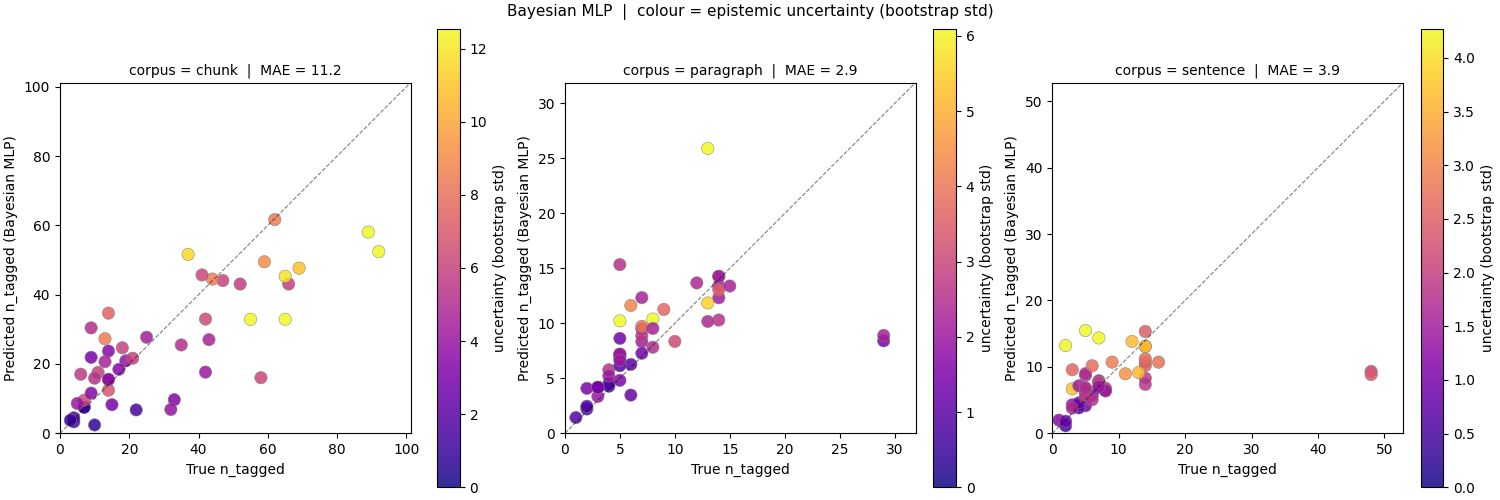

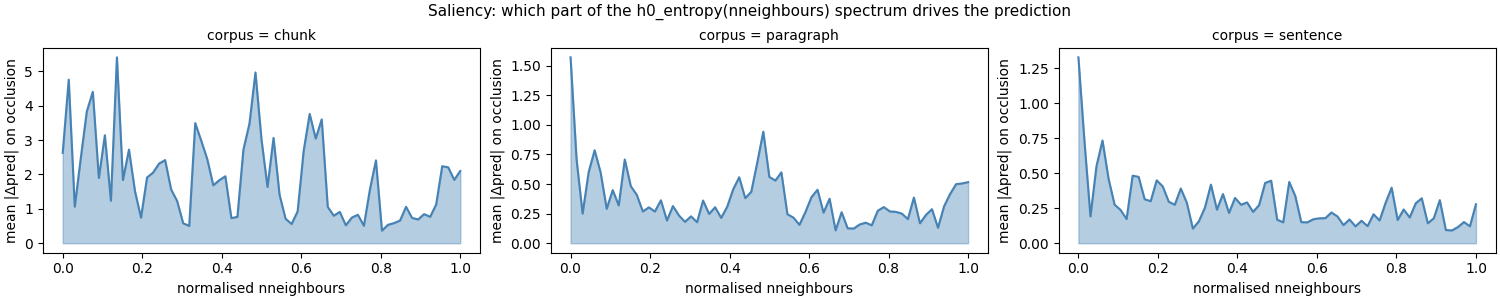

,unique_id,corpus_granularity,n_tagged,nn_predicted,uncertainty,abs_error
0,CI Definition Includes Third Party Info | Proj...,chunk,37.0,51.616791,11.544216,14.616791
1,CI Definition Includes Third Party Info | Proj...,paragraph,5.0,4.813731,1.507093,0.186269
2,CI Definition Includes Third Party Info | Proj...,sentence,5.0,4.145303,0.939351,0.854697
3,CI Definition Industry Specific Terms | SRT ND...,chunk,15.0,8.243649,3.081868,6.756351
4,CI Definition Industry Specific Terms | SRT ND...,paragraph,3.0,3.347227,1.958282,0.347227
...,...,...,...,...,...,...
142,Venue Exclusive | SRT NDA Master Template (OTP...,paragraph,7.0,12.336621,2.223712,5.336621
143,Venue Exclusive | SRT NDA Master Template (OTP...,sentence,7.0,7.000087,1.412539,0.000087
144,Venue | Project Greenlight - KHLP3 - OTPP NDA....,chunk,17.0,18.444901,3.374709,1.444901
145,Venue | Project Greenlight - KHLP3 - OTPP NDA....,paragraph,5.0,10.222539,6.452498,5.222539


In [48]:

# Bayesian MLP test run

data_para = df0.query("query_granularity=='paragraph'")

mlp_best = optimise_bayes_mlp(data_para, n_trials=40)
df_mlp_eval, saliency, de_grid = train_and_eval_bayes_mlp(data_para, mlp_best)

print("\n=== Bayesian MLP error summary ===")
print(df_mlp_eval.groupby("corpus_granularity")[["abs_error", "uncertainty"]].describe().round(2))

# ── scatter: predicted vs true, coloured by uncertainty ──────────────────────
cgs = sorted(df_mlp_eval["corpus_granularity"].unique())
fig, axes = plt.subplots(1, len(cgs), figsize=(5 * len(cgs), 5), constrained_layout=True)
if len(cgs) == 1:
    axes = [axes]

for ax, cg in zip(axes, cgs):
    sub = df_mlp_eval[df_mlp_eval["corpus_granularity"] == cg].dropna()
    lim = max(sub[["n_tagged", "nn_predicted"]].max().max() * 1.1, 5)
    sc_ = ax.scatter(sub["n_tagged"], sub["nn_predicted"],
                     c=sub["uncertainty"], cmap="plasma",
                     vmin=0, vmax=sub["uncertainty"].quantile(0.95),
                     s=80, alpha=0.85, edgecolors="grey", linewidths=0.4)
    fig.colorbar(sc_, ax=ax, label="uncertainty (bootstrap std)")
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.5)
    ax.set_xlabel("True n_tagged", fontsize=10)
    ax.set_ylabel("Predicted n_tagged (Bayesian MLP)", fontsize=10)
    ax.set_title(f"corpus = {cg}  |  MAE = {sub['abs_error'].mean():.1f}", fontsize=10)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")

plt.suptitle("Bayesian MLP  |  colour = epistemic uncertainty (bootstrap std)", fontsize=11)
plt.show()

# ── saliency: mean occlusion sensitivity per corpus granularity ───────────────
fig, axes = plt.subplots(1, len(cgs), figsize=(5 * len(cgs), 3), constrained_layout=True)
if len(cgs) == 1:
    
    axes = [axes]

for ax, cg in zip(axes, cgs):
    mask = df_mlp_eval["corpus_granularity"].values == cg
    if not mask.any():
        ax.set_visible(False); continue
    mean_sal = saliency[mask].mean(axis=0)
    ax.fill_between(de_grid, mean_sal, alpha=0.4, color="steelblue")
    ax.plot(de_grid, mean_sal, color="steelblue", lw=1.5)
    ax.set_xlabel("normalised nneighbours", fontsize=10)
    ax.set_ylabel("mean |Δpred| on occlusion", fontsize=10)
    ax.set_title(f"corpus = {cg}", fontsize=10)

plt.suptitle("Saliency: which part of the h0_entropy(nneighbours) spectrum drives the prediction",
             fontsize=11)
plt.show()

df_mlp_eval


In [43]:
import pickle
with open("/Users/thomas.barillot/AvantiaTech/data_platform/scripts/ottp_topology_analysis/outputs/simulation_lookup_table.pkl", "rb") as f:
    lookup = pickle.load(f)
    
lookup = pd.read_pickle("/Users/thomas.barillot/AvantiaTech/data_platform/scripts/ottp_topology_analysis/outputs/simulation_lookup_table.pkl")

In [44]:
lookup

,n_shared,noise,depsilon,w1_h0,h0_entropy,nneighbours
0,1,0.0,0.010000,NaN,NaN,50
1,1,0.0,0.012836,NaN,NaN,50
2,1,0.0,0.016475,NaN,NaN,50
3,1,0.0,0.021147,NaN,NaN,50
4,1,0.0,0.027144,NaN,NaN,50
...,...,...,...,...,...,...
995,10,0.2,1.473613,0.390217,2.234878,50
996,10,0.2,1.891483,0.390217,2.234878,50
997,10,0.2,2.427849,0.390217,2.234878,50
998,10,0.2,3.116311,0.390217,2.234878,50


((1, 0.0),     n_shared  noise  depsilon  w1_h0  h0_entropy  nneighbours
0          1    0.0  0.010000    NaN         NaN           50
1          1    0.0  0.012836    NaN         NaN           50
2          1    0.0  0.016475    NaN         NaN           50
3          1    0.0  0.021147    NaN         NaN           50
4          1    0.0  0.027144    NaN         NaN           50
5          1    0.0  0.034841    NaN         NaN           50
6          1    0.0  0.044721    NaN         NaN           50
7          1    0.0  0.057403    NaN         NaN           50
8          1    0.0  0.073681    NaN         NaN           50
9          1    0.0  0.094574    NaN         NaN           50
10         1    0.0  0.121392    NaN         NaN           50
11         1    0.0  0.155816    NaN         NaN           50
12         1    0.0  0.200000    NaN         NaN           50
13         1    0.0  0.256714    NaN         NaN           50
14         1    0.0  0.329510    NaN         NaN           

/var/folders/_y/xppx9k6x641c77hdcfkn8qm80000gn/T/ipykernel_5866/2264156962.py:5: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,1)
/var/folders/_y/xppx9k6x641c77hdcfkn8qm80000gn/T/ipykernel_5866/2264156962.py:5: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,1)
/var/folders/_y/xppx9k6x641c77hdcfkn8qm80000gn/T/ipykernel_5866/2264156962.py:5: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,1)
/var/folders/_y/xppx9k6x641c77hdcfkn8qm80000gn/T/ipykernel_5866/2264156962.py:5: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,1)
/var/folders/_y/xppx9k6x641c77hdcfkn8qm80000gn/T/ipykernel_5866/2264156962.py:5: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,1)
/var/folders/_y/xppx9k6x641c77hdcfkn8qm80000gn/T/ipykernel_5866/2264156962.py:5: UserWarning: A

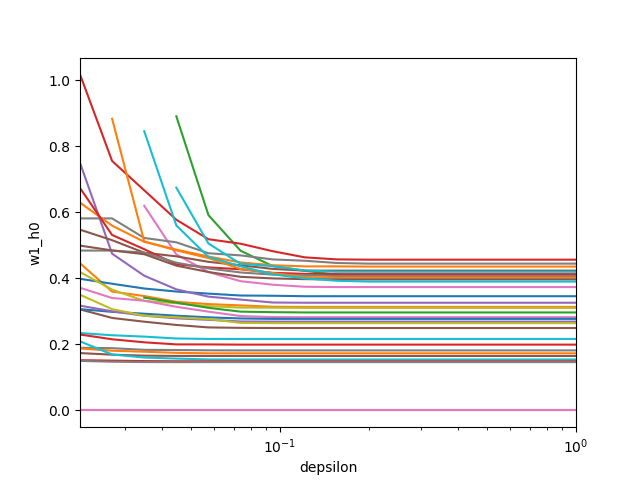

In [51]:
plt.figure()
for subdf in lookup.groupby(["n_shared", "noise"]):
    print(subdf)
    sns.lineplot(subdf[1], x="depsilon", y="w1_h0")
    plt.xlim(0,1)
    plt.xscale("log")